## Only taking 1 feature into consideration and predicting one hour ahead

In [26]:
import pandas as pd

df = pd.read_csv(
    "final_dataset.csv", parse_dates=["time"], index_col="time"
)

df.describe()

,fossil_fuels,windpower,solarpower,other_green_energy,total_load_actual,price_day_ahead,price_actual,day_of_week,hour_of_day,price_actual_lag_24h,...,windpower_lag_24h,solarpower_lag_24h,other_green_energy_lag_24h,total_load_actual_lag_24h,temp,wind_speed,clouds_all,temp_lag_24h,wind_speed_lag_24h,clouds_all_lag_24h
count,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,...,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000
mean,10605.591373,5437.463378,1437.377951,4376.580978,28676.479923,49.889318,57.704104,3.504420,12.000000,57.705422,...,5440.522927,1437.503169,4376.890759,28681.235622,289.880536,2.476477,24.552221,289.874241,2.478542,24.975837
std,3942.492001,3213.157687,1682.935662,2104.946034,4556.172023,14.604980,14.159318,1.665748,6.493681,14.164590,...,3213.145199,1682.949105,2105.138241,4557.500136,7.929103,2.041420,30.397016,7.924433,2.056698,30.729571
min,2673.000000,234.000000,2.000000,1225.000000,18041.000000,2.060000,9.330000,1.000000,1.000000,9.330000,...,234.000000,2.000000,1225.000000,18041.000000,265.624500,0.000000,0.000000,264.132000,0.000000,0.000000
25%,7382.000000,2909.000000,71.000000,2671.000000,24806.000000,41.500000,49.230000,2.000000,6.750000,49.230000,...,2911.000000,71.000000,2670.000000,24808.000000,284.090000,1.000000,0.000000,284.080000,1.000000,0.000000
50%,10386.000000,4814.000000,620.000000,3915.000000,28892.500000,50.520000,57.890000,3.600000,12.000000,57.890000,...,4819.000000,620.000000,3916.000000,28897.500000,289.330000,2.000000,20.000000,289.330000,2.000000,20.000000
75%,13268.000000,7351.000000,2594.000000,5693.000000,32153.000000,60.510000,67.810000,5.000000,17.250000,67.810000,...,7354.000000,2594.000000,5693.000000,32159.250000,295.420000,4.000000,40.000000,295.340000,4.000000,40.000000
max,28085.000000,17436.000000,5792.000000,12259.000000,41015.000000,101.990000,116.800000,6.000000,23.000000,116.800000,...,17436.000000,5792.000000,12259.000000,41015.000000,315.150000,29.000000,100.000000,315.150000,30.000000,100.000000


In [27]:
# Check for Missing Values
df.isnull().sum()

,0
fossil_fuels,0
windpower,0
solarpower,0
other_green_energy,0
total_load_actual,0
price_day_ahead,0
price_actual,0
day_of_week,0
hour_of_day,0
price_actual_lag_24h,0


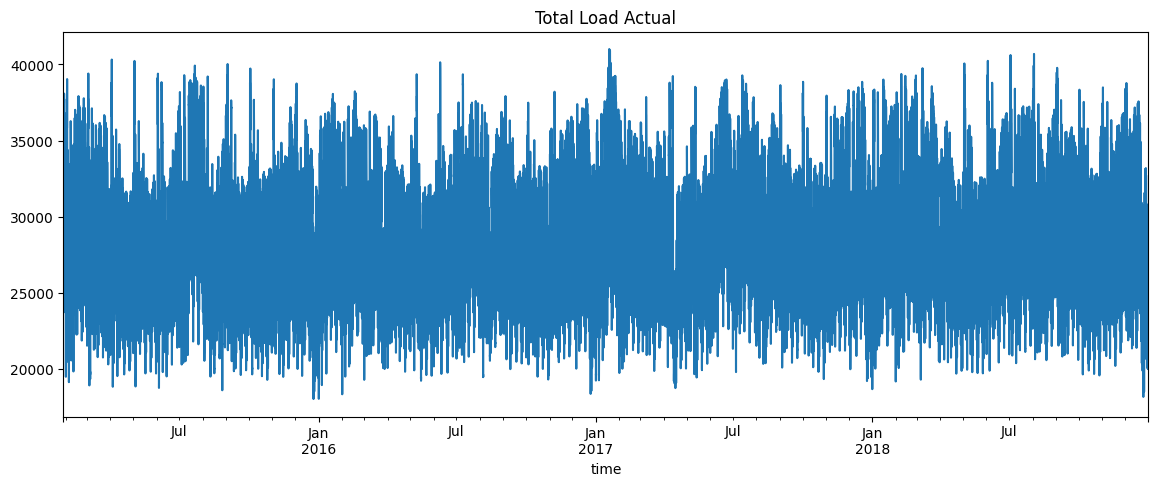

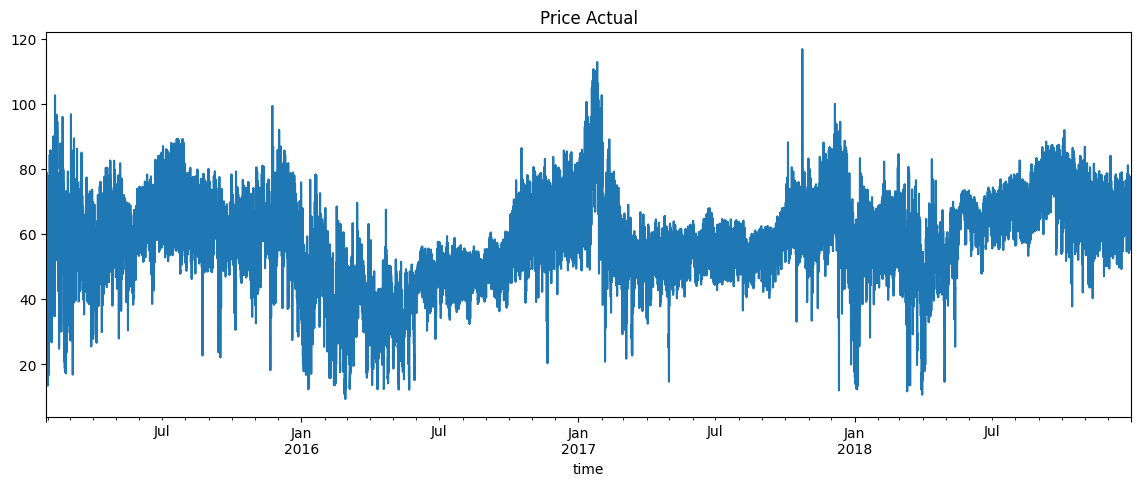

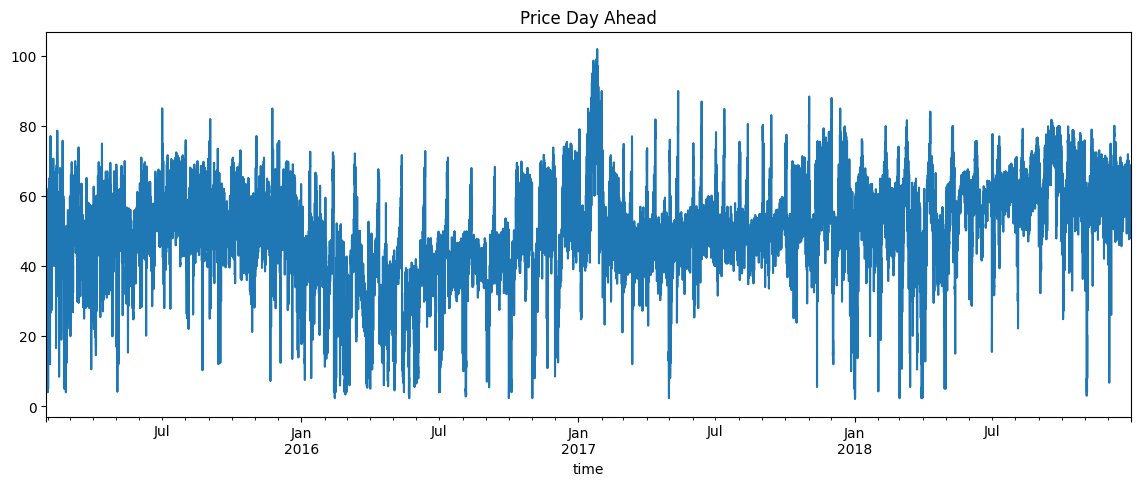

In [28]:
import matplotlib.pyplot as plt

df["total_load_actual"].plot(figsize=(14, 5), title="Total Load Actual")
plt.show()

df["price_actual"].plot(figsize=(14, 5), title="Price Actual")
plt.show()

df["price_day_ahead"].plot(figsize=(14, 5), title="Price Day Ahead")
plt.show()

In [29]:
corr = df.corr()
print(corr["price_actual"].sort_values(ascending=False))

ValueError: could not convert string to float: '2015-01-28 23:00:00'

In [30]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
df = pd.read_csv(
    "final_dataset.csv", parse_dates=["time"], index_col="time"
)

# Select the target variable (e.g., price actual)
y = df["price_actual"].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y)

In [31]:
import numpy as np

def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequence_length = 24  # Use past 24 hours to predict next hour
X, y = create_sequences(y_scaled, sequence_length)

# Reshape data for LSTM (samples, time steps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [32]:
# Split data into train and test sets
split_index = int(0.8 * len(X))  # 80% train, 20% test
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))  # Output layer with 1 neuron (for regression)
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0171
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0016
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.7524e-04
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.6259e-04
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.0585e-04
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.2185e-04
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.8547e-04
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.8098e-04
Epoch 9/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.2591e-04
Epoch 10/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.4380e-04


In [35]:
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict on test set
y_pred = model.predict(X_test)

# Invert scaling for evaluation
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
mae_lstm = mean_absolute_error(y_test_inv, y_pred_inv)
mse_lstm = mean_squared_error(y_test_inv, y_pred_inv)
rmse_lstm = np.sqrt(mse_lstm)

print(f"LSTM MAE: {mae_lstm:.2f}")
print(f"LSTM RMSE: {rmse_lstm:.2f}")

215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM MAE: 2.29
LSTM RMSE: 2.87


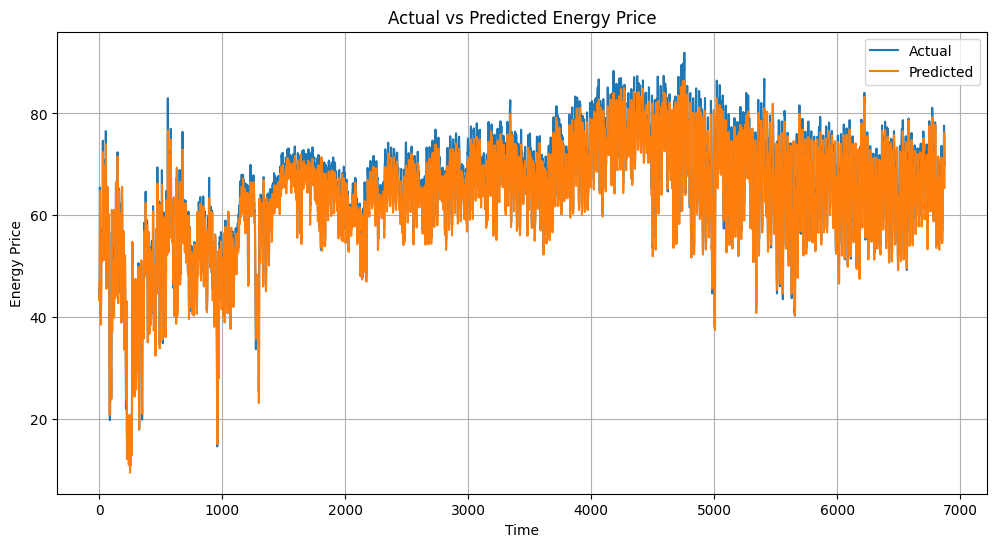

In [36]:
import matplotlib.pyplot as plt

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('Actual vs Predicted Energy Price')
plt.xlabel('Time')
plt.ylabel('Energy Price')
plt.legend()
plt.grid(True)
plt.show()

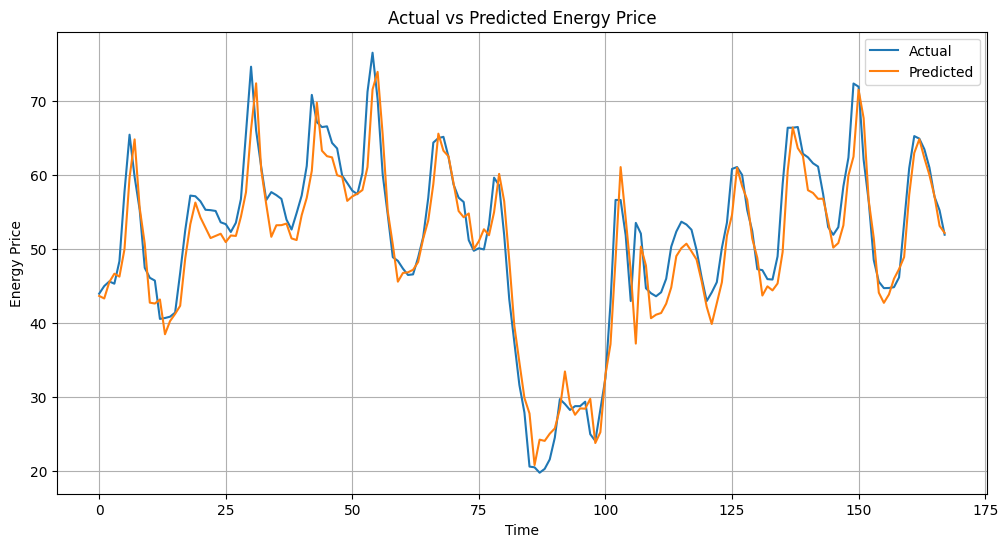

In [37]:
import matplotlib.pyplot as plt

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:7*24], label='Actual')
plt.plot(y_pred_inv[:7*24], label='Predicted')
plt.title('Actual vs Predicted Energy Price')
plt.xlabel('Time')
plt.ylabel('Energy Price')
plt.legend()
plt.grid(True)
plt.show()

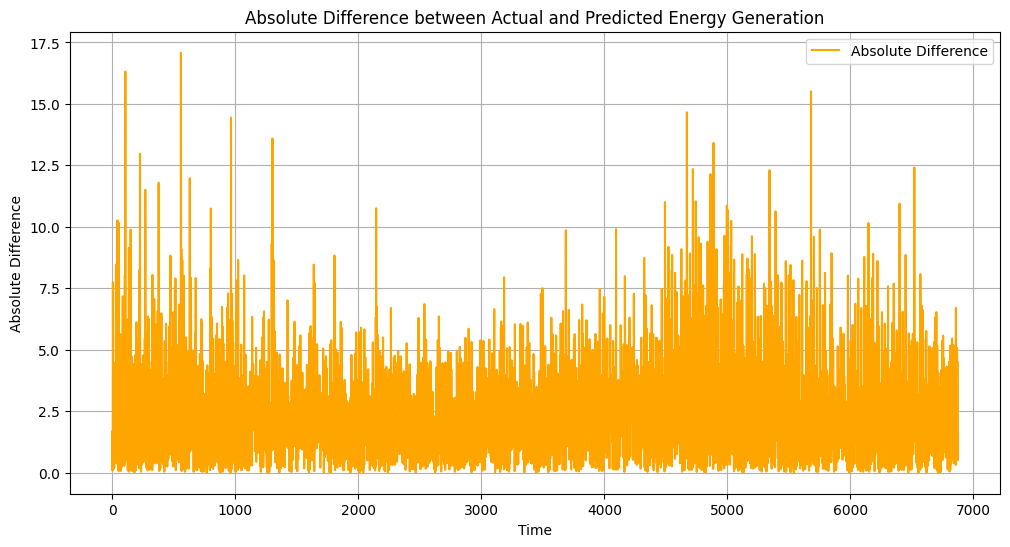

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate absolute difference
abs_diff = np.abs(y_test_inv - y_pred_inv)

# Plot absolute difference
plt.figure(figsize=(12, 6))
plt.plot(abs_diff, label='Absolute Difference', color='orange')
plt.title('Absolute Difference between Actual and Predicted Energy Generation')
plt.xlabel('Time')
plt.ylabel('Absolute Difference')
plt.legend()
plt.grid(True)
plt.show()

## More Features

In [39]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Load the data
data = pd.read_csv('final_dataset.csv', parse_dates=['time'], index_col='time')

df.describe()

,fossil_fuels,windpower,solarpower,other_green_energy,total_load_actual,price_day_ahead,price_actual,day_of_week,hour_of_day,price_actual_lag_24h,...,windpower_lag_24h,solarpower_lag_24h,other_green_energy_lag_24h,total_load_actual_lag_24h,temp,wind_speed,clouds_all,temp_lag_24h,wind_speed_lag_24h,clouds_all_lag_24h
count,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,...,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000,34392.000000
mean,10605.591373,5437.463378,1437.377951,4376.580978,28676.479923,49.889318,57.704104,3.504420,12.000000,57.705422,...,5440.522927,1437.503169,4376.890759,28681.235622,289.880536,2.476477,24.552221,289.874241,2.478542,24.975837
std,3942.492001,3213.157687,1682.935662,2104.946034,4556.172023,14.604980,14.159318,1.665748,6.493681,14.164590,...,3213.145199,1682.949105,2105.138241,4557.500136,7.929103,2.041420,30.397016,7.924433,2.056698,30.729571
min,2673.000000,234.000000,2.000000,1225.000000,18041.000000,2.060000,9.330000,1.000000,1.000000,9.330000,...,234.000000,2.000000,1225.000000,18041.000000,265.624500,0.000000,0.000000,264.132000,0.000000,0.000000
25%,7382.000000,2909.000000,71.000000,2671.000000,24806.000000,41.500000,49.230000,2.000000,6.750000,49.230000,...,2911.000000,71.000000,2670.000000,24808.000000,284.090000,1.000000,0.000000,284.080000,1.000000,0.000000
50%,10386.000000,4814.000000,620.000000,3915.000000,28892.500000,50.520000,57.890000,3.600000,12.000000,57.890000,...,4819.000000,620.000000,3916.000000,28897.500000,289.330000,2.000000,20.000000,289.330000,2.000000,20.000000
75%,13268.000000,7351.000000,2594.000000,5693.000000,32153.000000,60.510000,67.810000,5.000000,17.250000,67.810000,...,7354.000000,2594.000000,5693.000000,32159.250000,295.420000,4.000000,40.000000,295.340000,4.000000,40.000000
max,28085.000000,17436.000000,5792.000000,12259.000000,41015.000000,101.990000,116.800000,6.000000,23.000000,116.800000,...,17436.000000,5792.000000,12259.000000,41015.000000,315.150000,29.000000,100.000000,315.150000,30.000000,100.000000


In [66]:
# Select features and target
features = data[['day_of_week', 'hour_of_day', 'fossil_fuels', 'windpower', 'solarpower', 'other_green_energy',
                 'total_load_actual', 'price_day_ahead',
                 'price_actual_lag_24h', 'price_actual_lag_1w',
                 'price_actual_lag_2w', 'price_actual_lag_3w', 'price_actual_lag_4w',
                 'fossil_fuels_lag_24h', 'windpower_lag_24h', 'solarpower_lag_24h',
                 'other_green_energy_lag_24h', 'total_load_actual_lag_24h',
                 'temp', 'wind_speed', 'clouds_all', 'temp_lag_24h', 'wind_speed_lag_24h',
                 'clouds_all_lag_24h']]
target = data['price_actual']  # target to forecast

# Scale features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(features)
y_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1))

# Define a function to create sequences
def create_sequences(X, y, lookback=24, forecast_horizon=24):
    Xs, ys = [], []
    for i in range(len(X) - lookback - forecast_horizon + 1):
        Xs.append(X[i:(i+lookback)])
        ys.append(y[i+lookback+forecast_horizon-1])
    return np.array(Xs), np.array(ys)

lookback = 24  # number of past hours as input
forecast_horizon = 24  # forecast 24 hours ahead

X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback, forecast_horizon)

# Split into training and testing sets (e.g., 80/20 split)
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# Build the LSTM model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

# Forecast on test set
y_pred = model.predict(X_test)

# Inverse transform the predictions and true values if needed
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# Evaluate (for instance, using RMSE)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f'RMSE: {rmse:.2f}')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                        │ (None, 50)                  │          15,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,051 (58.79 KB)

 Trainable params: 15,051 (58.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0168 - val_loss: 0.0089
Epoch 2/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0048 - val_loss: 0.0082
Epoch 3/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0040 - val_loss: 0.0081
Epoch 4/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0040 - val_loss: 0.0085
Epoch 5/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0036 - val_loss: 0.0085
Epoch 6/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0037 - val_loss: 0.0083
Epoch 7/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0033 - val_loss: 0.0087
Epoch 8/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0031 - val_loss: 0.0084
Epoch 9/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0028 - val_loss: 0.0083
Epoch 10/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0026 - val_loss: 0.0085
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RMSE: 8.68


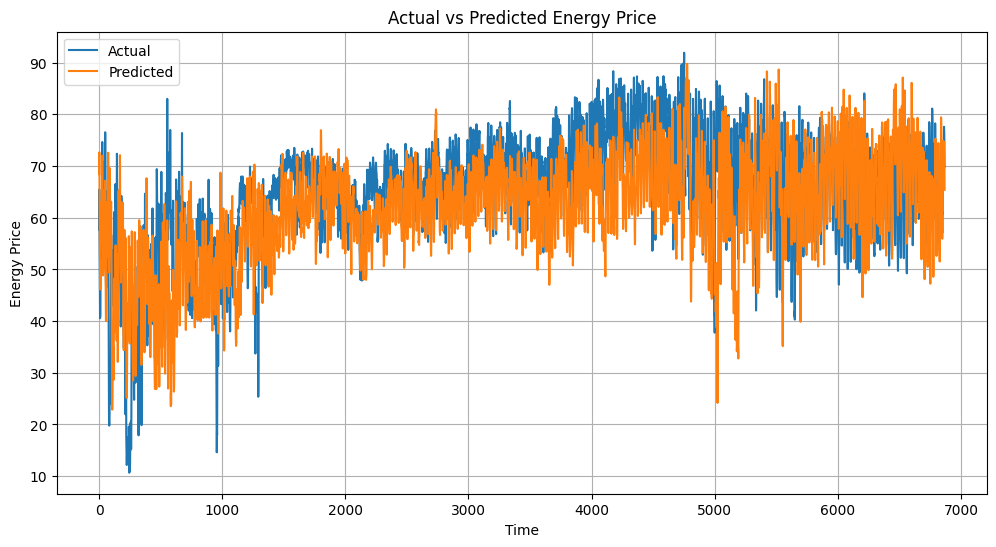

In [41]:
import matplotlib.pyplot as plt

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('Actual vs Predicted Energy Price')
plt.xlabel('Time')
plt.ylabel('Energy Price')
plt.legend()
plt.grid(True)
plt.show()

## 16/3
Taking all features into consideration and predicting 24 hours ahead

In [95]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import MinMaxScaler

# Load the data
data = pd.read_csv('final_dataset.csv', parse_dates=['time'], index_col='time')

# Select features and target
features = data[['price_actual_lag_24h', 'price_actual_lag_1w',
                 'price_actual_lag_2w', 'price_actual_lag_3w', 'price_actual_lag_4w',
                 'fossil_fuels_lag_24h', 'windpower_lag_24h', 'solarpower_lag_24h',
                 'other_green_energy_lag_24h', 'total_load_actual_lag_24h',
                 'temp_lag_24h', 'wind_speed_lag_24h',
                 'clouds_all_lag_24h']]

target = data['price_actual']

In [96]:
# Scale features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(features)
y_scaled = scaler_y.fit_transform(target.values.reshape(-1, 1))

In [97]:
import numpy as np

def create_sequences(data, input_sequence_length, prediction_horizon):
    X, y = [], []
    # Loop until there's enough room for a full prediction horizon
    for i in range(input_sequence_length, len(data) - prediction_horizon + 1):
        X.append(data[i - input_sequence_length:i, 0])
        # Append the next 'prediction_horizon' values as the target sequence
        y.append(data[i:i + prediction_horizon, 0])
    return np.array(X), np.array(y)

input_sequence_length = 24  # Use past 24 hours as input
prediction_horizon = 24     # Predict the next 24 hours
X, y = create_sequences(y_scaled, input_sequence_length, prediction_horizon)

# Reshape X for LSTM (samples, time steps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)  # Expected: (num_samples, 24, 1)
print("y shape:", y.shape)  # Expected: (num_samples, 24)

X shape: (34345, 24, 1)
y shape: (34345, 24)


In [98]:
# Split data into train and test sets
split_index = int(0.8 * len(X))  # 80% train, 20% test
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("num_train_samples:", 0.8 * X.shape[0]) # Expected: (num_samples * 0.8 = 27476)
print("X_train shape:", X_train.shape)  # Expected: (num_train_samples, 24, 1)
print("y_train shape:", y_train.shape)  # Expected: (num_train_samples, 24

num_train_samples: 27476.0
X_train shape: (27476, 24, 1)
y_train shape: (27476, 24)


In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

input_sequence_length = 24  # past 24 hours
prediction_horizon = 24     # predict next 24 hours

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(input_sequence_length, 1)))
# The Dense layer outputs 24 values for the 24-hour forecast
model.add(Dense(prediction_horizon))
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                       │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 24)                  │           1,224 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,624 (45.41 KB)

 Trainable params: 11,624 (45.41 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0299 - val_loss: 0.0118
Epoch 2/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0073 - val_loss: 0.0101
Epoch 3/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0065 - val_loss: 0.0093
Epoch 4/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0061 - val_loss: 0.0085
Epoch 5/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0056 - val_loss: 0.0080
Epoch 6/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0052 - val_loss: 0.0070
Epoch 7/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0048 - val_loss: 0.0067
Epoch 8/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0045 - val_loss: 0.0066
Epoch 9/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0045 - val_loss: 0.0064
Epoch 10/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0044 - val_loss: 0.0062


In [101]:
y_pred = model.predict(X_test)

215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [102]:
# Invert scaling for evaluation
y_pred_inv = scaler_y.inverse_transform(y_pred)  # Shape: (n_samples, 24)
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1))  # Shape: (n_samples*24, 1)

# Flatten both arrays to 1D vectors
y_pred_inv_flat = y_pred_inv.flatten()
y_test_inv_flat = y_test_inv.flatten()

# Calculate metrics
mae = mean_absolute_error(y_test_inv_flat, y_pred_inv_flat)
mse_ = mean_squared_error(y_test_inv_flat, y_pred_inv_flat)
rmse = np.sqrt(mse_)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


MAE: 4.2654
RMSE: 5.8899


In [103]:
prediction_horizon = 24  # number of forecast hours

# Invert scaling and reshape y_test to (n_samples, 24)
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape[0], prediction_horizon)
y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape[0], prediction_horizon)

print("y_test_inv shape:", y_test_inv.shape)
print("y_pred_inv shape:", y_pred_inv.shape)

y_test_inv shape: (6869, 24)
y_pred_inv shape: (6869, 24)


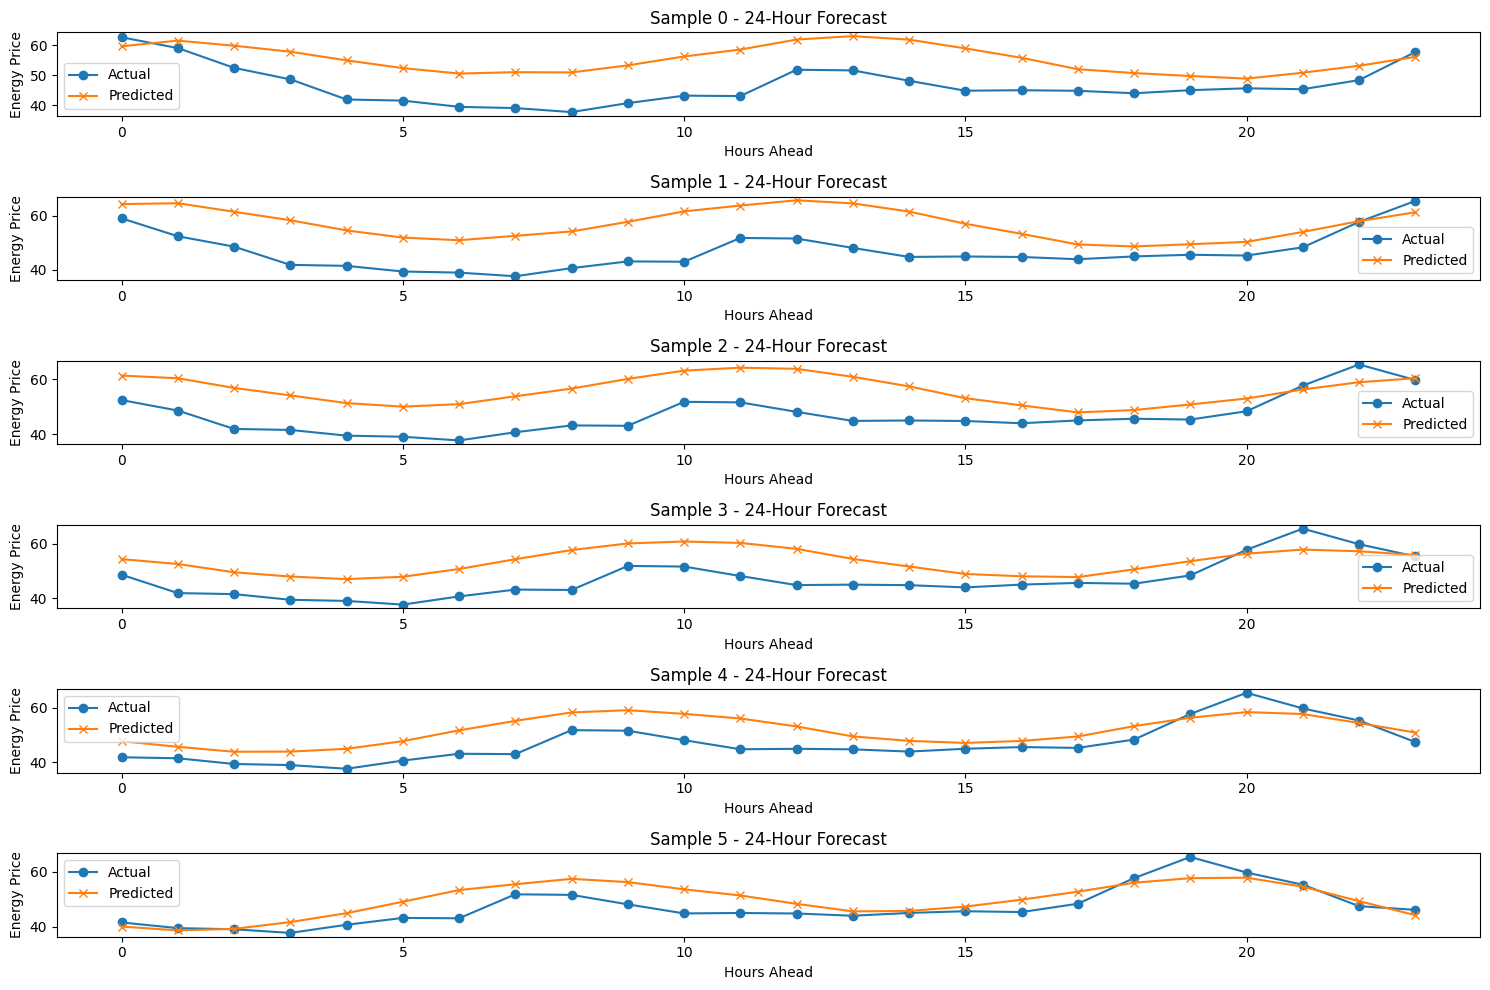

In [104]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import numpy as np

num_samples_to_plot = 6
plt.figure(figsize=(15, 10))
for i in range(num_samples_to_plot):
    plt.subplot(num_samples_to_plot, 1, i+1)
    plt.plot(range(24), y_test_inv[i], marker='o', label='Actual')
    plt.plot(range(24), y_pred_inv[i], marker='x', label='Predicted')
    plt.xlabel('Hours Ahead')
    plt.ylabel('Energy Price')
    plt.title(f'Sample {i} - 24-Hour Forecast')
    plt.legend()
plt.tight_layout()
plt.show()


In [51]:
print(y_pred_inv.shape)
print(y_test_inv.shape)

(6869, 24)
(164856, 1)


In [52]:
print("X shape:", X.shape)  # Expected: (n_samples, 24)
print("y shape:", y.shape)  # Expected: (n_samples, 24)

X shape: (34345, 24, 1)
y shape: (34345, 24)
